In [1]:
# %pip install numpy pandas matplotlib scipy scikit-learn

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import AgglomerativeClustering
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, adjusted_rand_score
from scipy.spatial.distance import pdist, squareform
from scipy.cluster.hierarchy import linkage, dendrogram

plt.rcParams.update({'figure.figsize': (9, 5), 'font.size': 10})
print('Libraries imported successfully.')

Libraries imported successfully.


In [3]:
iris = load_iris()
X = iris.data
y_true = iris.target
df = pd.DataFrame(X, columns=iris.feature_names)
print('Dataset shape:', df.shape)
print('Missing values:', int(df.isna().sum().sum()))
display(df.head())

Dataset shape: (150, 4)
Missing values: 0


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [4]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
N_CLUSTERS = 3
print('Feature means:', np.round(X_scaled.mean(axis=0), 3))
print('Feature standard deviations:', np.round(X_scaled.std(axis=0), 3))

Feature means: [-0. -0. -0. -0.]
Feature standard deviations: [1. 1. 1. 1.]


In [5]:
agg_model = AgglomerativeClustering(n_clusters=N_CLUSTERS, linkage='ward')
agg_labels = agg_model.fit_predict(X_scaled)
print('Agglomerative cluster sizes:')
print(pd.Series(agg_labels).value_counts().sort_index().to_string())

Agglomerative cluster sizes:
0    71
1    49
2    30


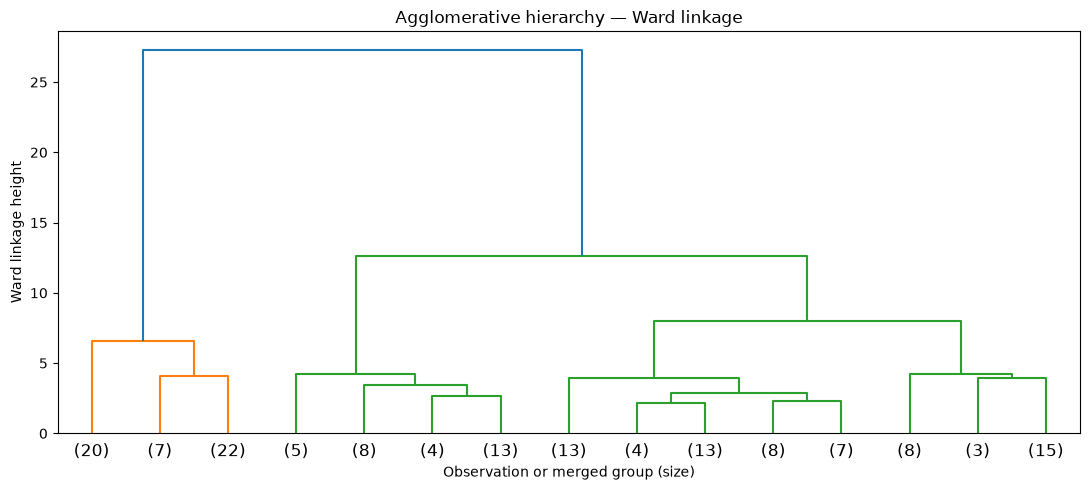

In [6]:
Z_agg = linkage(X_scaled, method='ward')
plt.figure(figsize=(11, 5))
dendrogram(Z_agg, truncate_mode='lastp', p=15, show_leaf_counts=True)
plt.title('Agglomerative hierarchy — Ward linkage')
plt.xlabel('Observation or merged group (size)')
plt.ylabel('Ward linkage height')
plt.tight_layout()
plt.show()

In [7]:
def splinter_split(members, distances):
    """Divide one non-singleton cluster into two non-empty groups."""
    members = list(members)
    within = distances[np.ix_(members, members)]
    mean_distances = within.sum(axis=1) / (len(members) - 1)
    seed = members[int(np.argmax(mean_distances))]
    splinter = [seed]
    remaining = [i for i in members if i != seed]

    while len(remaining) > 1:
        differences = []
        for i in remaining:
            others = [j for j in remaining if j != i]
            to_remaining = distances[i, others].mean()
            to_splinter = distances[i, splinter].mean()
            differences.append(to_remaining - to_splinter)
        best = int(np.argmax(differences))
        if differences[best] <= 0:
            break
        splinter.append(remaining.pop(best))
    return remaining, splinter


def divisive_clustering(data, n_clusters=3):
    """Return chosen labels, full split tree, and chronological split history."""
    data = np.asarray(data, dtype=float)
    if data.ndim != 2 or len(data) < 2 or not np.isfinite(data).all():
        raise ValueError('Provide at least two rows of finite numeric features.')
    n = len(data)
    if not isinstance(n_clusters, (int, np.integer)) or not 1 <= n_clusters <= n:
        raise ValueError('n_clusters must be an integer between 1 and n_samples.')
    distances = squareform(pdist(data, metric='euclidean'))
    root = tuple(range(n))
    active = [root]
    tree, history = {}, []
    chosen = list(active) if n_clusters == 1 else None

    while len(active) < n:
        candidates = [(float(distances[np.ix_(c, c)].max()), pos)
                      for pos, c in enumerate(active) if len(c) > 1]
        diameter, position = max(candidates, key=lambda item: item[0])
        parent = active.pop(position)
        left, right = splinter_split(parent, distances)
        left, right = tuple(left), tuple(right)
        tree[parent] = (left, right, diameter)
        active.extend([left, right])
        history.append({'step': len(history) + 1, 'parent_size': len(parent),
                        'left_size': len(left), 'right_size': len(right),
                        'diameter': diameter, 'clusters_after_split': len(active)})
        if len(active) == n_clusters:
            chosen = list(active)

    labels = np.empty(n, dtype=int)
    for label, members in enumerate(chosen):
        labels[list(members)] = label
    return labels, tree, pd.DataFrame(history)


def divisive_linkage(tree, n_samples):
    """Encode the split tree in SciPy format for dendrogram visualization."""
    rows = []
    def visit(node):
        if len(node) == 1:
            return node[0]
        left, right, height = tree[node]
        left_id = visit(left)
        right_id = visit(right)
        node_id = n_samples + len(rows)
        rows.append([left_id, right_id, height, len(node)])
        return node_id
    visit(tuple(range(n_samples)))
    return np.asarray(rows, dtype=float)

print('Divisive clustering functions are ready.')

Divisive clustering functions are ready.


In [8]:
div_labels, div_tree, split_history = divisive_clustering(X_scaled, N_CLUSTERS)
print('Divisive cluster sizes:')
print(pd.Series(div_labels).value_counts().sort_index().to_string())
print('First five splits (the first two produce our three-cluster partition):')
display(split_history.head())

Divisive cluster sizes:
0    50
1    56
2    44
First five splits (the first two produce our three-cluster partition):


,step,parent_size,left_size,right_size,diameter,clusters_after_split
0,1,150,100,50,6.529323,2
1,2,100,56,44,5.828015,3
2,3,50,24,26,5.051063,4
3,4,44,41,3,3.216237,5
4,5,41,32,9,3.216237,6


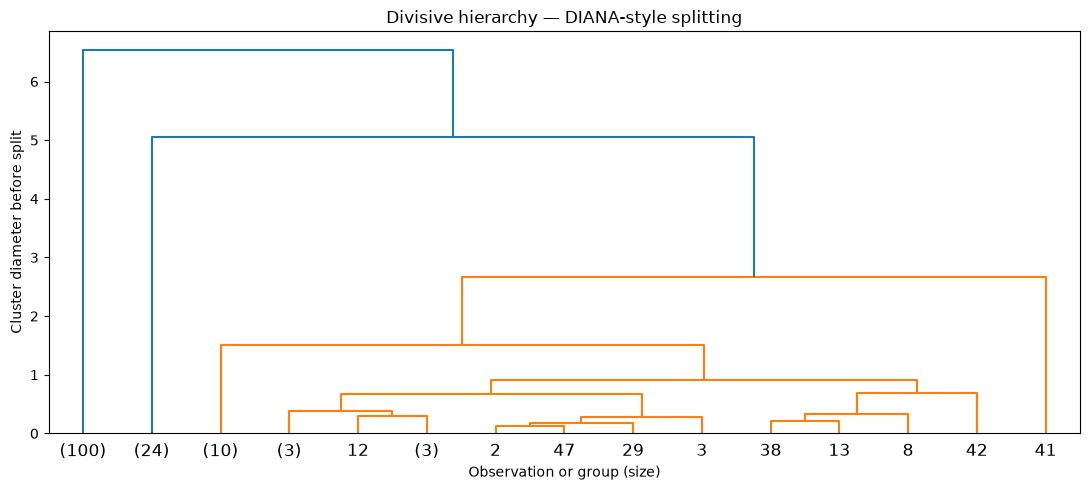

In [9]:
Z_div = divisive_linkage(div_tree, len(X_scaled))
plt.figure(figsize=(11, 5))
dendrogram(Z_div, truncate_mode='lastp', p=15, show_leaf_counts=True)
plt.title('Divisive hierarchy — DIANA-style splitting')
plt.xlabel('Observation or group (size)')
plt.ylabel('Cluster diameter before split')
plt.tight_layout()
plt.show()

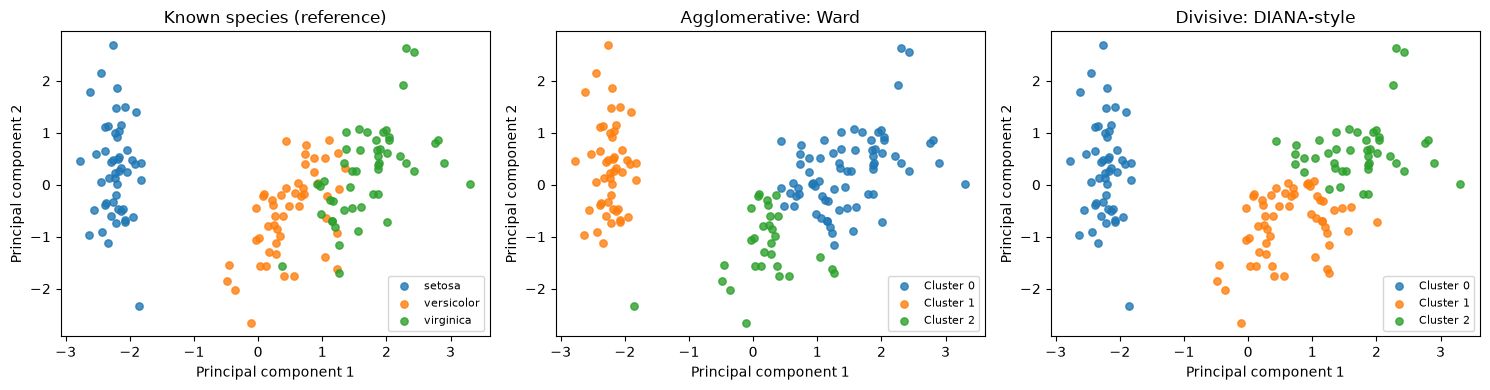

Variance represented by the 2D plot: 95.8%


In [10]:
pca = PCA(n_components=2)
X_plot = pca.fit_transform(X_scaled)
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, labels, title in zip(axes, [y_true, agg_labels, div_labels],
                           ['Known species (reference)', 'Agglomerative: Ward', 'Divisive: DIANA-style']):
    for group in np.unique(labels):
        mask = labels == group
        name = iris.target_names[group] if title.startswith('Known') else f'Cluster {group}'
        ax.scatter(X_plot[mask, 0], X_plot[mask, 1], label=name, s=28, alpha=0.8)
    ax.set_title(title)
    ax.set_xlabel('Principal component 1')
    ax.set_ylabel('Principal component 2')
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()
print(f'Variance represented by the 2D plot: {pca.explained_variance_ratio_.sum():.1%}')

In [11]:
comparison = pd.DataFrame([
    {'Method': name, 'Clusters': len(np.unique(labels)),
     'Silhouette': silhouette_score(X_scaled, labels),
     'ARI vs species': adjusted_rand_score(y_true, labels)}
    for name, labels in [('Agglomerative (Ward)', agg_labels),
                         ('Divisive (DIANA-style)', div_labels)]
])
display(comparison.round(4))
assignments = df.copy()
assignments['Species'] = iris.target_names[y_true]
assignments['Agglomerative cluster'] = agg_labels
assignments['Divisive cluster'] = div_labels
display(assignments.head(10))
best = comparison.loc[comparison['Silhouette'].idxmax(), 'Method']
print('Higher silhouette score in this run:', best)

,Method,Clusters,Silhouette,ARI vs species
0,Agglomerative (Ward),3,0.4467,0.6153
1,Divisive (DIANA-style),3,0.4630,0.5923


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),Species,Agglomerative cluster,Divisive cluster
0,5.1,3.5,1.4,0.2,setosa,1,0
1,4.9,3.0,1.4,0.2,setosa,1,0
2,4.7,3.2,1.3,0.2,setosa,1,0
3,4.6,3.1,1.5,0.2,setosa,1,0
4,5.0,3.6,1.4,0.2,setosa,1,0
5,5.4,3.9,1.7,0.4,setosa,1,0
6,4.6,3.4,1.4,0.3,setosa,1,0
7,5.0,3.4,1.5,0.2,setosa,1,0
8,4.4,2.9,1.4,0.2,setosa,1,0
9,4.9,3.1,1.5,0.1,setosa,1,0


Higher silhouette score in this run: Divisive (DIANA-style)


In [12]:
assert len(np.unique(agg_labels)) == N_CLUSTERS
assert len(np.unique(div_labels)) == N_CLUSTERS
assert len(div_tree) == len(X_scaled) - 1
for parent, (left, right, height) in div_tree.items():
    assert left and right
    assert set(left).isdisjoint(right)
    assert set(left) | set(right) == set(parent)
tiny = np.array([[0.0], [0.1], [10.0], [10.1]])
tiny_labels, _, _ = divisive_clustering(tiny, 2)
assert tiny_labels[0] == tiny_labels[1]
assert tiny_labels[2] == tiny_labels[3]
assert tiny_labels[0] != tiny_labels[2]
for k in [1, len(tiny)]:
    labels, _, _ = divisive_clustering(tiny, k)
    assert len(np.unique(labels)) == k
print('All partition and splitting checks passed.')

All partition and splitting checks passed.
